**Import Libraries**

In [3]:
# AAI201 Final Capstone
# Project: Predicting NBA Player Performance Using Machine Learning Models
# Name: DeJanee McAtee

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight

**Upload Dataset**


In [4]:
#mounted Google Drive to upload dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#load dataset and check first 5 rows

df = pd.read_csv("/content/drive/MyDrive/AAI 201/Final Project/Datasets/nbadailyleadersfull2425.csv")

df.head()

,Player,Tm,Unnamed: 3,Opp,Result,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,+/-,GmSc,Date
0,Jayson Tatum,BOS,NaN,NYK,W,30:18,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,26.0,38.1,2024-10-22
1,Anthony Davis,LAL,NaN,MIN,W,37:35,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,1.0,34.0,2024-10-22
2,Derrick White,BOS,NaN,NYK,W,26:38,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,21.0,22.4,2024-10-22
3,Jrue Holiday,BOS,NaN,NYK,W,30:31,7,9,0.778,4,6,0.667,0,0,NaN,2,2,4,4,1,0,0,2,18,23.0,19.5,2024-10-22
4,Miles McBride,NYK,@,BOS,L,25:51,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,-18.0,17.8,2024-10-22


In [6]:
print(df.shape) #rows and columns
print(df.columns) #column names
df.info() #number of rows (data points - games), columns (features), non-null
          # count, and data types

(28265, 27)
Index(['Player', 'Tm', 'Unnamed: 3', 'Opp', 'Result', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', '+/-', 'GmSc', 'Date'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28265 entries, 0 to 28264
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      28265 non-null  object 
 1   Tm          28265 non-null  object 
 2   Unnamed: 3  14057 non-null  object 
 3   Opp         28265 non-null  object 
 4   Result      28265 non-null  object 
 5   MP          28265 non-null  object 
 6   FG          28265 non-null  int64  
 7   FGA         28265 non-null  int64  
 8   FG%         26622 non-null  float64
 9   3P          28265 non-null  int64  
 10  3PA         28265 non-null  int64  
 11  3P%         22448 non-null  float64
 12  FT          28265 non-null  int64  
 13  FTA         28265

**Clean Up**

In [7]:
#convert MP column to numeric minutes

def convert_minutes(mp):
    if pd.isna(mp):
      return np.nan
    minutes, seconds = str(mp).split(":")
    return int(minutes) + int(seconds) / 60

df["MP_numeric"] = df["MP"].apply(convert_minutes)
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
#drop unnecessary home/away column

df = df.drop(columns=["Unnamed: 3"], errors="ignore")

In [9]:
#fill percentage NaNs with 0

percent_cols = ["FG%", "3P%","FT%"]
df[percent_cols] = df[percent_cols].fillna(0)

In [10]:
#fill remaining missing values

numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

**Target Variable**

Fixed scoring threshold:
- GoodGame = 1 if the player scored 20+ points, otherwise 0

In [11]:
SCORING_THRESHOLD = 20

df["GoodGame"] = (df["PTS"] >= SCORING_THRESHOLD).astype(int)
df["GoodGame"].value_counts()

,count
GoodGame,
0,23720
1,4545


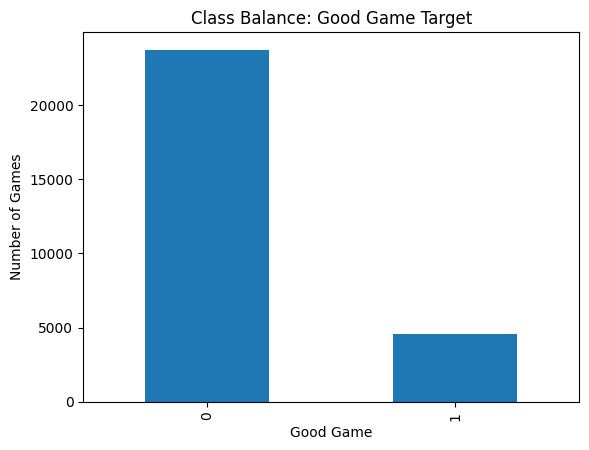

GoodGame
0    23720
1     4545
Name: count, dtype: int64
GoodGame
0    0.8392
1    0.1608
Name: count, dtype: float64


In [12]:
#Check class balance

class_counts = df["GoodGame"].value_counts()
class_counts.plot(kind="bar")
plt.title("Class Balance: Good Game Target")
plt.xlabel("Good Game")
plt.ylabel("Number of Games")
plt.show()

print(class_counts)
print(class_counts / len(df))

Note: The dataset exhibits class imbalance, with approximately 84% of observations belonging to the negative class and 16% to the positive class. To address this, class weighting and evaluation metrics such as precision, recall, and F1-score will be used instead of accuracy alone.

**Feature Engineering**

Use of rolling averages

In [13]:
#Sort data by player and date first

df = df.sort_values(["Player", "Date"])

In [14]:
#Create rolling averages from previous games only,
#drop early games where rolling window isn't valid, and
#prevent data leakage

rolling_features = ["PTS", "MP_numeric", "FGA", "FG%", "3PA", "3P%", "FTA", "FT%",
                    "TRB", "AST", "STL", "BLK", "TOV", "GmSc"]

for col in rolling_features:
  df[f"{col}_rolling3"] = (
      df.groupby("Player")[col]
      .transform(lambda x: x.shift(1)
      .rolling(window=3, min_periods=3)
      .mean())
  )

#drop rows where rolling columns are missing

rolling_cols = [f"{col}_rolling3" for col in rolling_features]
df = df.dropna(subset=rolling_cols)

In [15]:
df["GoodGame"].value_counts()
df["GoodGame"].value_counts(normalize=True).round(4)

,proportion
GoodGame,
0,0.8352
1,0.1648


**Feature Selection & Target**

In [16]:
feature_cols = [col for col in df.columns if "rolling3" in col]

X = df[feature_cols]
y = df["GoodGame"]

print(X.head())
print(y.value_counts())

      PTS_rolling3  MP_numeric_rolling3  ...  TOV_rolling3  GmSc_rolling3
1108      4.666667             9.394444  ...      0.333333       4.000000
1582      5.666667             8.950000  ...      0.333333       4.200000
2113      2.666667             6.777778  ...      0.333333       1.300000
2681      8.000000            13.811111  ...      0.333333       6.866667
2905     11.000000            19.038889  ...      0.666667       9.700000

[5 rows x 14 columns]
GoodGame
0    22199
1     4379
Name: count, dtype: int64


Feature selection focused on rolling 3-game averages to capture recent player performance trends while preventing data leakage by excluding current-game stats. The target variable ("GoodGame") remains imbalanced (~84% negative, ~16% positive), requiring the use of class balancing techniques and appropriate evaluation metrics.

**Train/Validation/Test Split**

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (18604, 14)
Validation: (3987, 14)
Test: (3987, 14)


The dataset was split into 70% training, 15% validation, and 15% testing sets using stratified sampling to preserve class distribution across all subsets. This ensures reliable model evaluation, particularly given the class imbalance in the target variable.

**Feature Scaling (for Naïve Bayes and MLP)**

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

**Decision Tree**

In [19]:
dt_model = DecisionTreeClassifier(
    max_depth = 5,
    min_samples_leaf = 20,
    class_weight = "balanced",
    random_state = 42
)

dt_model.fit(X_train, y_train)

dt_val_preds = dt_model.predict(X_val)

print("Decision Tree Validation Results")
print(classification_report(y_val, dt_val_preds))

Decision Tree Validation Results
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      3330
           1       0.44      0.78      0.56       657

    accuracy                           0.80      3987
   macro avg       0.69      0.79      0.71      3987
weighted avg       0.86      0.80      0.82      3987



**Decision Tree Breakdown**

The Decision Tree model achieved high recall (0.80) for the positive class, indicating strong ability to identify ‘GoodGame’ instances. However, precision was lower (0.44), suggesting a higher rate of false positives. This tradeoff is expected due to class balancing and reflects the model prioritizing detection of rare positive outcomes.

**Naïve Bayes**

In [20]:
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_val_preds = nb_model.predict(X_val_scaled)

print("Naïve Bayes Validation Results")
print(classification_report(y_val, nb_val_preds))

Naïve Bayes Validation Results
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      3330
           1       0.45      0.75      0.56       657

    accuracy                           0.81      3987
   macro avg       0.70      0.78      0.72      3987
weighted avg       0.86      0.81      0.83      3987



**Naïve Bayes**

Although Naïve Bayes performed comparably to the Decision Tree, its underlying assumption of feature independence is violated in this dataset. Many rolling statistics are inherently correlated. As a result, while Naïve Bayes provides a useful baseline, its predictions may be less reliable than models that can account for feature interactions.


**MLP Neural Network**

In [21]:
mlp_model = MLPClassifier(
    hidden_layer_sizes = (64, 32),
    activation = "relu",
    solver = "adam",
    alpha = 0.001,
    max_iter = 300,
    early_stopping = True,
    validation_fraction = 0.15,
    random_state = 42
)

mlp_model.fit(X_train_scaled, y_train)

mlp_val_preds = mlp_model.predict(X_val_scaled)

print("MLP Validation Results")
print(classification_report(y_val, mlp_val_preds))


MLP Validation Results
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      3330
           1       0.62      0.44      0.52       657

    accuracy                           0.86      3987
   macro avg       0.76      0.69      0.72      3987
weighted avg       0.85      0.86      0.85      3987



The MLP model achieved the highest overall accuracy (0.86) and the highest precision for the positive class (0.60), indicating more reliable predictions when identifying ‘Good Game’ outcomes. However, recall was lower (0.47), suggesting the model missed a larger portion of actual positive cases. This reflects a more conservative prediction strategy compared to tree-based models.

**Performance Comparison**

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt_val_preds,
    "Naïve Bayes": nb_val_preds,
    "MLP": mlp_val_preds
}

results = []

for name, preds in models.items():
  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_val, preds),
      "Precision": precision_score(y_val, preds, pos_label = 1),
      "Recall": recall_score(y_val, preds),
      "F1 Score": f1_score(y_val, preds)
  })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.797843,0.436703,0.782344,0.560523
1,Naïve Bayes,0.809882,0.453284,0.745814,0.563867
2,MLP,0.863807,0.622318,0.441400,0.516474


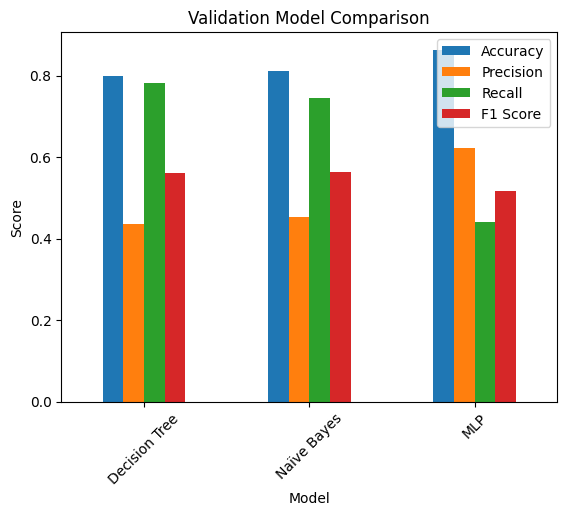

In [27]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind = "bar")
plt.title("Validation Model Comparison")
plt.xlabel("Model")
plt.xticks(rotation = 45)
plt.ylabel("Score")
plt.show()

The Decision Tree model achieved the highest recall (0.78), making it most effective at identifying ‘Good Game’ instances, though at the cost of lower precision. Naïve Bayes provided the best balance between precision and recall, resulting in the highest F1 score (0.56). The MLP achieved the highest overall accuracy (0.86) and precision (0.62), but had significantly lower recall (0.44), indicating a more conservative prediction approach. These results highlight the tradeoff between capturing positive cases and minimizing false positives.

**Best Model Test**

In [30]:
best_model_name = results_df.sort_values("F1 Score", ascending = False).iloc[0]["Model"]
print(best_model_name)

if best_model_name == "Decision Tree":
  final_preds = dt_model.predict(X_test)
elif best_model_name == "Naïve Bayes":
  final_preds = nb_model.predict(X_test_scaled)
else:
  final_preds = mlp_model.predict(X_test_scaled)

print("Final Test Results")
print(classification_report(y_test, final_preds))

Naïve Bayes
Final Test Results
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      3330
           1       0.48      0.77      0.59       657

    accuracy                           0.82      3987
   macro avg       0.71      0.80      0.74      3987
weighted avg       0.87      0.82      0.84      3987



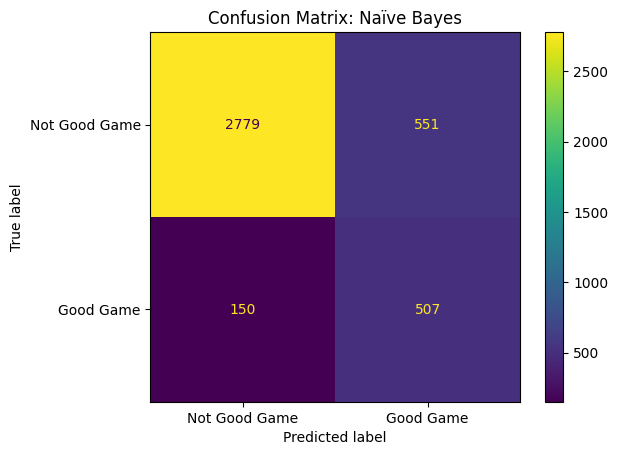

In [31]:
cm = confusion_matrix(y_test, final_preds)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Not Good Game", "Good Game"])
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

The confusion matrix shows that the model correctly identified 507 ‘Good Game’ instances while missing 150. This results in a high recall, indicating strong ability to detect positive performances. However, 551 false positives suggest the model occasionally over-predicts good games, reflecting a tradeoff between recall and precision.

**Reflection**

## Reflection

This project predicted whether an NBA player would score at least 20 points in a game using previous-game rolling averages.

The scoring threshold was defined as a fixed 20-point benchmark. This made the target variable easy to interpret and aligned with common basketball analysis.

Class imbalance was addressed by using stratified train/validation/test splits, prioritizing F1-score, and applying class weights to the Decision Tree model.

Naïve Bayes was included for comparison, but it may perform worse because many basketball statistics are correlated. For example, field goal attempts, points, usage, and game score are related, which violates Naïve Bayes' independence assumption.

Overfitting prevention techniques included limiting Decision Tree depth, using minimum leaf samples, applying early stopping in the MLP, and using regularization in the neural network.

The final model was selected based on validation F1-score and evaluated on the test set.